<a href="https://colab.research.google.com/github/jmora420-hue/Ciencia_de_datos/blob/main/Diabetes_Tarea_Resuelta_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid") # Color de paleta
ARCHIVO = "/content/drive/MyDrive/Colab Notebooks/diabetes (1).xlsx"

# Cargamos el dataset indicando que la coma es el separador decimal
df = pd.read_excel(ARCHIVO, decimal=',')

# Limpiamos los nombres de las columnas por si tienen espacios extra
df.columns = [str(c).strip() for c in df.columns]

# Eliminamos filas que puedan tener valores vacíos (NA)
df = df.dropna().copy()

# Mostramos los resultados en lugar de las "Palabras totales"
print(f"Total de registros cargados: {len(df)}")

Total de registros cargados: 768


In [ ]:
def gini(valores):
    x = np.sort(np.asarray(valores, dtype=float))
    if len(x) == 0 or x.sum() == 0:
        return np.nan
    n = len(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) / (n * x.sum())) - (n + 1) / n

def entropia_normalizada(valores):
    p = np.asarray(valores, dtype=float)
    p = p[p > 0]
    if len(p) == 0:
        return np.nan

    p = p / p.sum()
    h = -np.sum(p * np.log2(p))
    return h / np.log2(len(p)) if len(p) > 1 else 0.0

In [ ]:
def resumen_estadistico(df, columna):
    f = df[columna]
    modos = f.mode().tolist()

    return pd.Series({
        "Variable": columna,
        "Total de registros": int(f.size),
        "Valores únicos": f.nunique(),
        "Media": f.mean(),
        "Mediana": f.median(),
        "Moda": ", ".join(map(str, modos)),
        "Mínimo": f.min(),
        "Máximo": f.max(),
        "Q1 (25%)": f.quantile(.25),
        "Q2 (50%)": f.quantile(.50),
        "Q3 (75%)": f.quantile(.75),
        "Índice de Gini": gini(f),
        "Entropía Norm.": entropia_normalizada(f)
    })


In [ ]:
print(resumen_estadistico(df, "Insulin"))
print(resumen_estadistico(df, "Glucose"))
print(resumen_estadistico(df, "Age"))
print(resumen_estadistico(df, "DiabetesPedigreeFunction"))

Variable                 Insulin
Total de registros           768
Valores únicos               187
Media                 141.753906
Mediana                    102.5
Moda                       102.5
Mínimo                      14.0
Máximo                     846.0
Q1 (25%)                   102.5
Q2 (50%)                   102.5
Q3 (75%)                   169.5
Índice de Gini          0.280509
Entropía Norm.          0.977275
dtype: object
Variable                 Glucose
Total de registros           768
Valores únicos               135
Media                 121.677083
Mediana                    117.0
Moda                     99, 100
Mínimo                        44
Máximo                       199
Q1 (25%)                   99.75
Q2 (50%)                   117.0
Q3 (75%)                  140.25
Índice de Gini          0.140604
Entropía Norm.          0.995374
dtype: object
Variable                    Age
Total de registros          768
Valores únicos               52
Media             

In [ ]:
df_HR = df[df["DiabetesPedigreeFunction"] > 0.5]

print(f"Registros encontrados de forma óptima: {len(df_HR)}")

Registros encontrados de forma óptima: 277


Primero lo que hice fue plantear una correlación entre la Insulina, la glucosa, la probabilidad de obtener diabetes y la edad, por eso le hago el resumen estadístico a esas 4 variables, a las cuales tener en cuenta.Decido filtrar por una PD mayor a 0.5, esto al ser mayor que la media aún teniendo en cuenta la mediana debido a que no tienen valores tan diferentes, y a esos nuevos datos les vuelvo a hacer el resumen estadístico para corroborar el planteamiento al comprar los valores de la media mediana y moda.

In [ ]:
print(resumen_estadistico(df_HR, "Insulin"))
print(resumen_estadistico(df, "Glucose"))
print(resumen_estadistico(df_HR, "Age"))
print(resumen_estadistico(df_HR, "DiabetesPedigreeFunction"))

Variable                 Insulin
Total de registros           277
Valores únicos               119
Media                 157.166065
Mediana                    148.0
Moda                       102.5
Mínimo                      14.0
Máximo                     744.0
Q1 (25%)                   102.5
Q2 (50%)                   148.0
Q3 (75%)                   169.5
Índice de Gini          0.295777
Entropía Norm.          0.971733
dtype: object
Variable                 Glucose
Total de registros           768
Valores únicos               135
Media                 121.677083
Mediana                    117.0
Moda                     99, 100
Mínimo                        44
Máximo                       199
Q1 (25%)                   99.75
Q2 (50%)                   117.0
Q3 (75%)                  140.25
Índice de Gini          0.140604
Entropía Norm.          0.995374
dtype: object
Variable                    Age
Total de registros          277
Valores únicos               45
Media             

Al comprar los valores de las cuatro variables según el filtrado con los datos de la población en general, se puede descartar el nivel de la glucosa como un factor de riesgo de la diabetes, pues sus valores de media y mediana son muy similares, la edad es un caso parecido, puesto que aunque aumenta un poco la media y la mediana al finjarnos en la moda, se nos indica que aún hay varia gente jovenn de 21 años que siguen suffriendo un PD alto; este proceso es itertivo, por lo que podemos seguir filtrando datos hasta llegar corroborar una correlación. Por lo que mi conclusión es que se puede llegar a establecer una manera de identificar factores de riesgo para la predicción de la Diabetes, sin embargo, este método al ser iterativo, es poco eficiente y está sujeto a posibles fallas de análisis por el manejo únicamente de las medidas de tendencia central, mientras  que para un estudio es necesacio muchas más maneras de poder corroborar su causalidad.

# **CONTINUACIÓN CON MEDIDAS CENTRALES**

In [ ]:
df.info()
!pip install wquantiles

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


### Análisis para la columna 'Insulin'

Percentiles para Insulin:
 0.05     50.0
0.25    102.5
0.50    102.5
0.75    169.5
0.95    293.0
Name: Insulin, dtype: float64


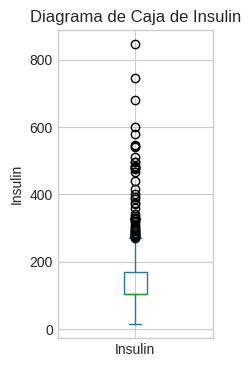

In [ ]:
# Calcular percentiles para 'Insulin'
percentiles_insulin = df["Insulin"].quantile([0.05, 0.25, 0.5, 0.75, 0.95])
print("Percentiles para Insulin:\n", percentiles_insulin)

# Diagrama de caja para 'Insulin'
ax_insulin_box = df["Insulin"].plot.box(figsize=(2,4))
ax_insulin_box.set_ylabel("Insulin")
plt.title("Diagrama de Caja de Insulin")
plt.show()

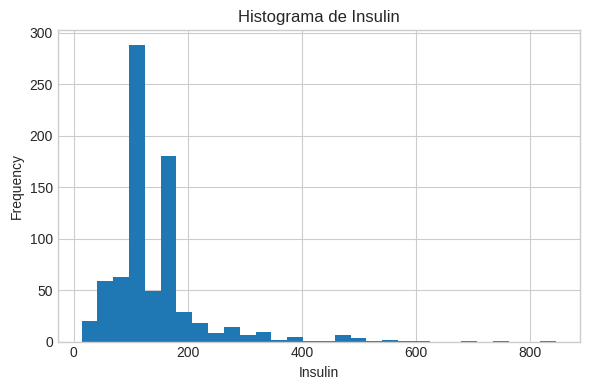

In [ ]:
# Histograma para 'Insulin'
ax_insulin_hist = df["Insulin"].plot.hist(figsize=(6,4), bins=30)
ax_insulin_hist.set_xlabel("Insulin")
plt.title("Histograma de Insulin")
plt.tight_layout()
plt.show()

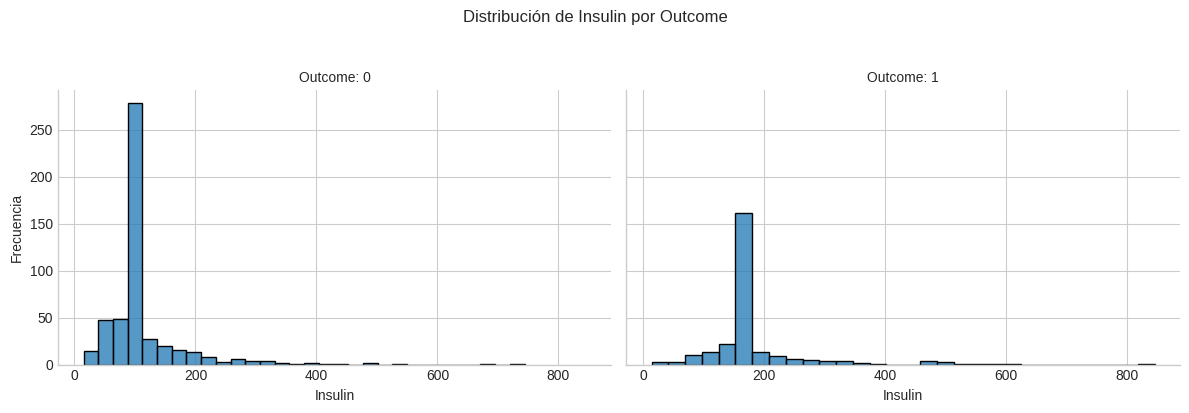

In [ ]:
# Visualización de gráficos en "facetas" por 'Outcome' para 'Insulin'
g_insulin_facet = sns.FacetGrid(df, col='Outcome', col_wrap=2, height=4, aspect=1.5)
g_insulin_facet.map(sns.histplot, 'Insulin', bins=30)
g_insulin_facet.set_axis_labels('Insulin', 'Frecuencia')
g_insulin_facet.set_titles(col_template='Outcome: {col_name}')
plt.suptitle('Distribución de Insulin por Outcome', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Análisis para la columna 'DiabetesPedigreeFunction'

Percentiles para DiabetesPedigreeFunction:
 0.05    0.14035
0.25    0.24375
0.50    0.37250
0.75    0.62625
0.95    1.13285
Name: DiabetesPedigreeFunction, dtype: float64


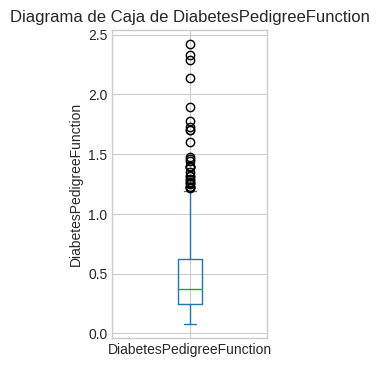

In [ ]:
# Calcular percentiles para 'DiabetesPedigreeFunction'
percentiles_dpf = df["DiabetesPedigreeFunction"].quantile([0.05, 0.25, 0.5, 0.75, 0.95])
print("Percentiles para DiabetesPedigreeFunction:\n", percentiles_dpf)

# Diagrama de caja para 'DiabetesPedigreeFunction'
ax_dpf_box = df["DiabetesPedigreeFunction"].plot.box(figsize=(2,4))
ax_dpf_box.set_ylabel("DiabetesPedigreeFunction")
plt.title("Diagrama de Caja de DiabetesPedigreeFunction")
plt.show()

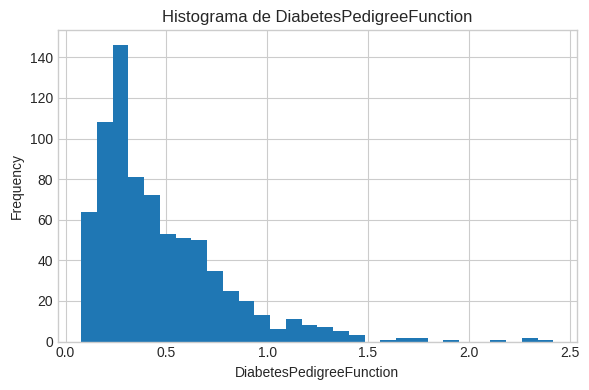

In [ ]:
# Histograma para 'DiabetesPedigreeFunction'
ax_dpf_hist = df["DiabetesPedigreeFunction"].plot.hist(figsize=(6,4), bins=30)
ax_dpf_hist.set_xlabel("DiabetesPedigreeFunction")
plt.title("Histograma de DiabetesPedigreeFunction")
plt.tight_layout()
plt.show()

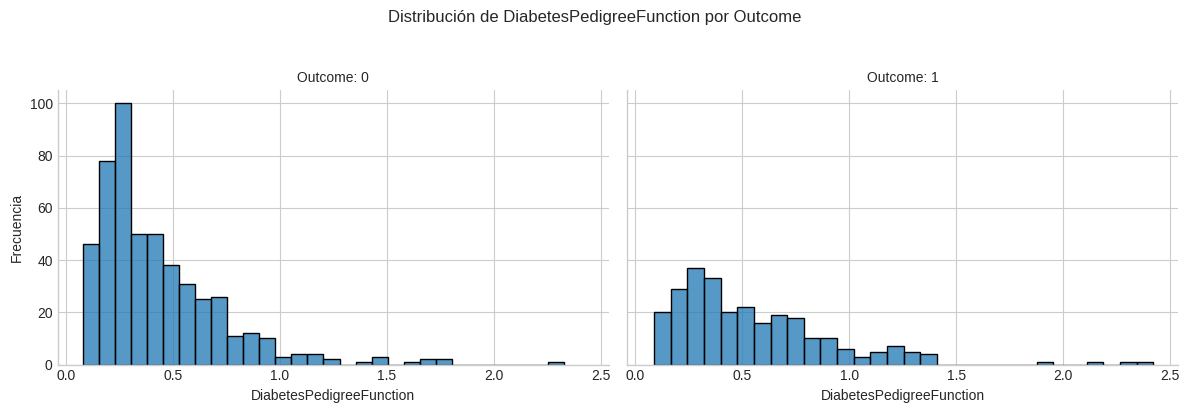

In [ ]:
# Visualización de gráficos en "facetas" por 'Outcome' para 'DiabetesPedigreeFunction'
g_dpf_facet = sns.FacetGrid(df, col='Outcome', col_wrap=2, height=4, aspect=1.5)
g_dpf_facet.map(sns.histplot, 'DiabetesPedigreeFunction', bins=30)
g_dpf_facet.set_axis_labels('DiabetesPedigreeFunction', 'Frecuencia')
g_dpf_facet.set_titles(col_template='Outcome: {col_name}')
plt.suptitle('Distribución de DiabetesPedigreeFunction por Outcome', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Viendo los datos por medio de la distribución de cada una de las variables a las que le habíamos planteado una correlación como indicador de la diabetes podemos darnos cuenta que basar el análisis únicamente por medio de las medidas de tendencia central fue erróneo, pues observando el diagrama de cajas notamos la gran cantidad de datos atípicos que afectan a la media y nos detenemos en los diagramas de distribución por Outcome, es decir, si tienen diabetes =1, si no, =0, notamos que la distribución de DiabetesPedigreeFunction es prácticamente igual en ambos casos, sin embargo la distribución de la insulina si muestra un gran cambio, siendo el valor más frecuente niveles de insulina de 200 unidades, para esto se volverá a tener en cuenta la edad y la glucosa como posible factor de riesgo

Percentiles para Age:
 0.05    21.0
0.25    24.0
0.50    29.0
0.75    41.0
0.95    58.0
Name: Age, dtype: float64


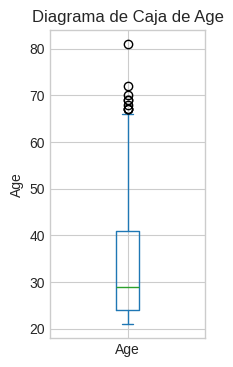

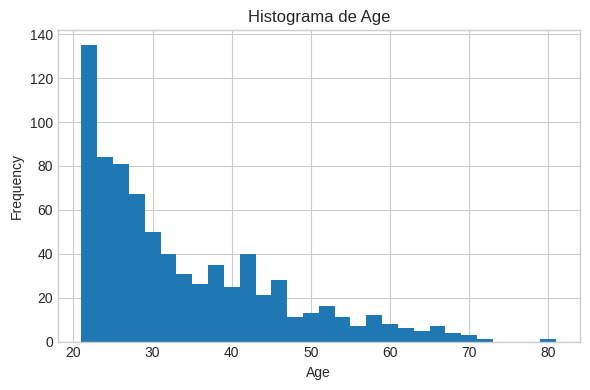

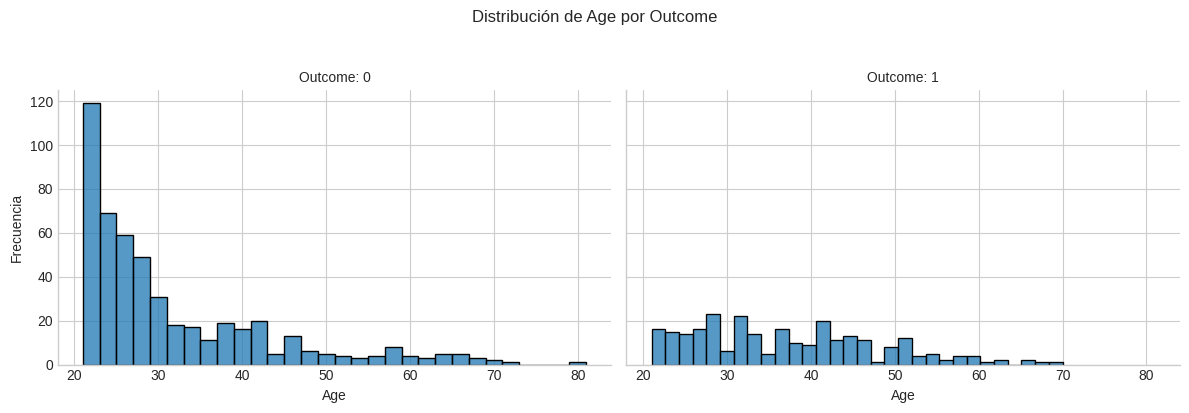

In [ ]:
# Calcular percentiles para 'Age'
percentiles_age = df["Age"].quantile([0.05, 0.25, 0.5, 0.75, 0.95])
print("Percentiles para Age:\n", percentiles_age)

# Diagrama de caja para 'Age'
ax_age_box = df["Age"].plot.box(figsize=(2,4))
ax_age_box.set_ylabel("Age")
plt.title("Diagrama de Caja de Age")
plt.show()

# Histograma para 'Age'
ax_age_hist = df["Age"].plot.hist(figsize=(6,4), bins=30)
ax_age_hist.set_xlabel("Age")
plt.title("Histograma de Age")
plt.tight_layout()
plt.show()

# Visualización de gráficos en "facetas" por 'Outcome' para 'Age'
g_age_facet = sns.FacetGrid(df, col='Outcome', col_wrap=2, height=4, aspect=1.5)
g_age_facet.map(sns.histplot, 'Age', bins=30)
g_age_facet.set_axis_labels('Age', 'Frecuencia')
g_age_facet.set_titles(col_template='Outcome: {col_name}')
plt.suptitle('Distribución de Age por Outcome', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Percentiles para Glucose:
 0.05     80.00
0.25     99.75
0.50    117.00
0.75    140.25
0.95    181.00
Name: Glucose, dtype: float64


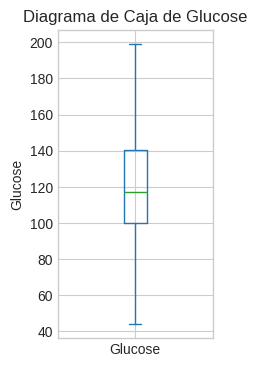

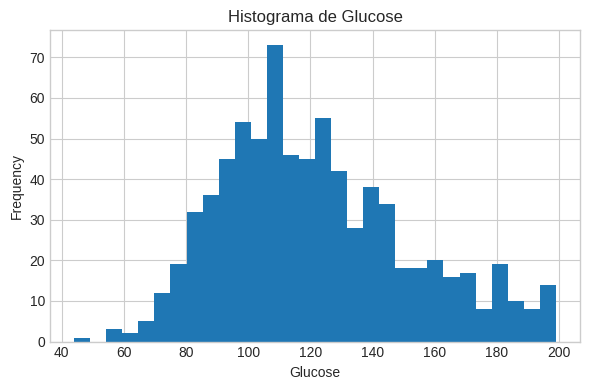

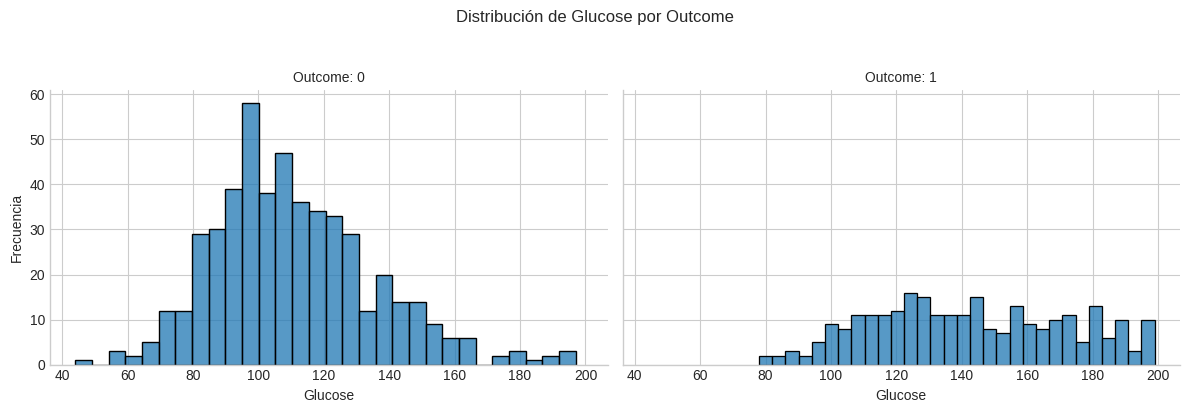

In [ ]:
# Calcular percentiles para 'Glucose'
percentiles_glucose = df["Glucose"].quantile([0.05, 0.25, 0.5, 0.75, 0.95])
print("Percentiles para Glucose:\n", percentiles_glucose)

# Diagrama de caja para 'Glucose'
ax_glucose_box = df["Glucose"].plot.box(figsize=(2,4))
ax_glucose_box.set_ylabel("Glucose")
plt.title("Diagrama de Caja de Glucose")
plt.show()

# Histograma para 'Glucose'
ax_glucose_hist = df["Glucose"].plot.hist(figsize=(6,4), bins=30)
ax_glucose_hist.set_xlabel("Glucose")
plt.title("Histograma de Glucose")
plt.tight_layout()
plt.show()

# Visualización de gráficos en "facetas" por 'Outcome' para 'Glucose'
g_glucose_facet = sns.FacetGrid(df, col='Outcome', col_wrap=2, height=4, aspect=1.5)
g_glucose_facet.map(sns.histplot, 'Glucose', bins=30)
g_glucose_facet.set_axis_labels('Glucose', 'Frecuencia')
g_glucose_facet.set_titles(col_template='Outcome: {col_name}')
plt.suptitle('Distribución de Glucose por Outcome', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Por lo que se logra observar y como se vio con las medidas de tendencia central, la edad no es un factor de riesgo para la diabetes, si es cierto que los jóvenes tienden a no tener diabetes, pero si comparamos la frecuencias en cada una de las edades, se puede oservar una gran similitud, si es cierto que a medida que aumenta la edad aumentan los casos de diabetes relativos para a esa edad, se deben tener en cuenta la cantidad de datos con esa edad, puesto que tanto las medidas de tendencia central como la distribución son directamente afectados por la cantidad de encuestados mayores a 30, entonces no podemos asegurar que por ejemplo sobre los 40 la propabilidad de tener diabetes aumente a un 50%, puesto que no se ve ningún incremento lineal o de cualquier otro tipo entre estas variables y se le puede atribuir a la falta de datos. Por otro lado, al ver la distribución de la glucosa se nota un gran cambio, ahora viendo valores sobre las 100 unidades con mucha más frecuencia, una correlación directa con la diabetes.